# Dimensionality Reduction and Feature Learning

## Dataset: Sklearn Digits

In [2]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler

digits     = load_digits()
X_dig      = digits.data          # (1797, 64) pixel intensities
y_dig      = digits.target        # ground-truth digit labels (0–9)
X_dig_sc   = MinMaxScaler().fit_transform(X_dig)

print("=== Digits ===")
print(f"  Observations : {X_dig.shape[0]:,}")
print(f"  Features     : {X_dig.shape[1]}  (8x8 pixel intensities, 0-16)")
print(f"  Classes      : {np.unique(y_dig).tolist()}  ({len(np.unique(y_dig))} digits)")

=== Digits ===
  Observations : 1,797
  Features     : 64  (8x8 pixel intensities, 0-16)
  Classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  (10 digits)


## Principal Component Analysis

### Scree Plot and Component Selection

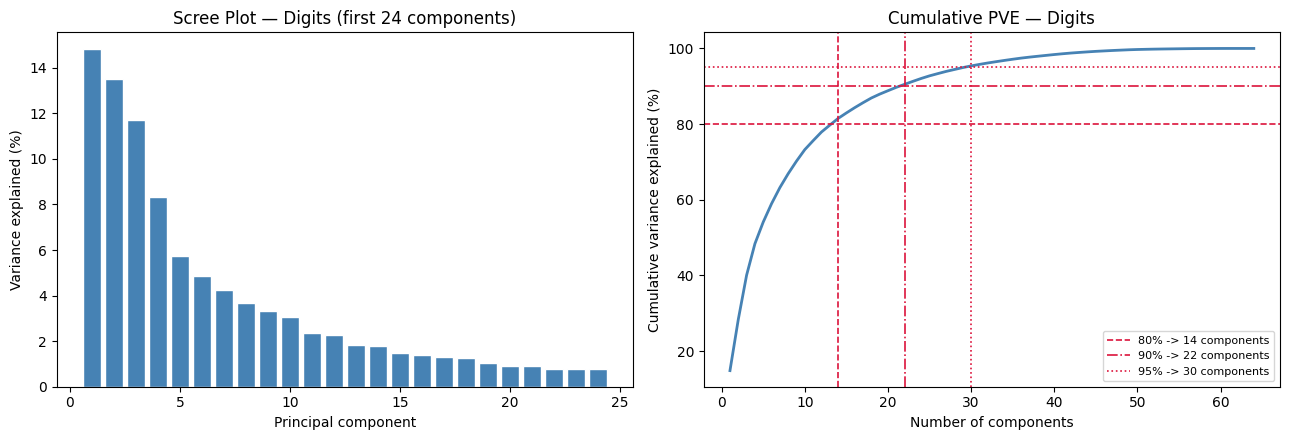

Components for 80% PVE : 14
Components for 90% PVE : 22
Components for 95% PVE : 30


In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parent))
from config import FIGURES, RANDOM_SEED

pca_full  = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_dig_sc)
pve       = pca_full.explained_variance_ratio_
cum_pve   = np.cumsum(pve)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, 25), pve[:24] * 100, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree Plot — Digits (first 24 components)")

axes[1].plot(range(1, 65), cum_pve * 100, color="steelblue", lw=2)
for target, ls in [(0.80, "--"), (0.90, "-."), (0.95, ":")]:
    n_comp = np.searchsorted(cum_pve, target) + 1
    axes[1].axhline(target * 100, color="crimson", lw=1.2, linestyle=ls,
                    label=f"{target:.0%} -> {n_comp} components")
    axes[1].axvline(n_comp, color="crimson", lw=1.2, linestyle=ls)
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance explained (%)")
axes[1].set_title("Cumulative PVE — Digits")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / "ch6_pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()

for target in [0.80, 0.90, 0.95]:
    n = np.searchsorted(cum_pve, target) + 1
    print(f"Components for {target:.0%} PVE : {n}")

### Visualising Components and the 2D Projection

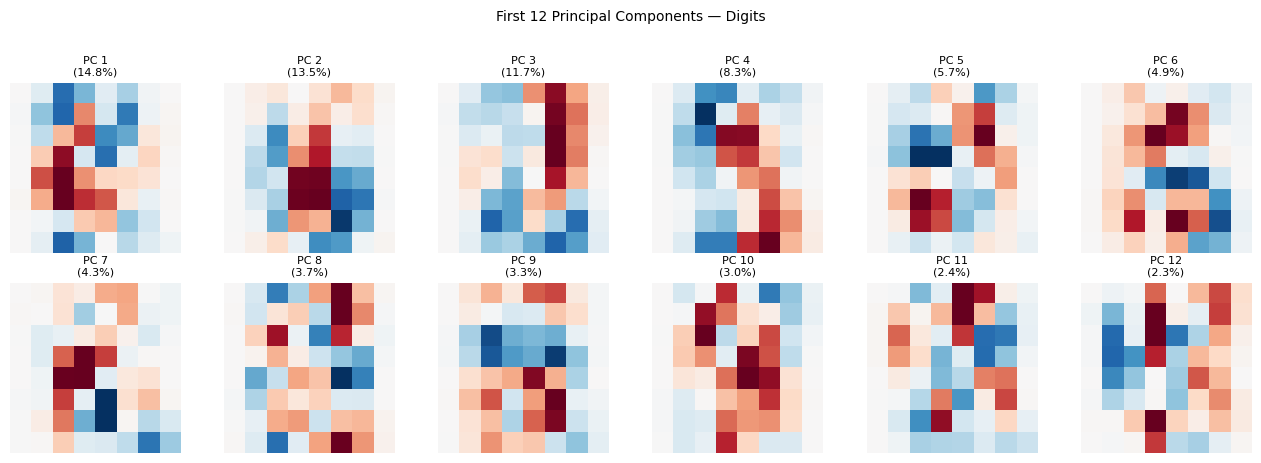

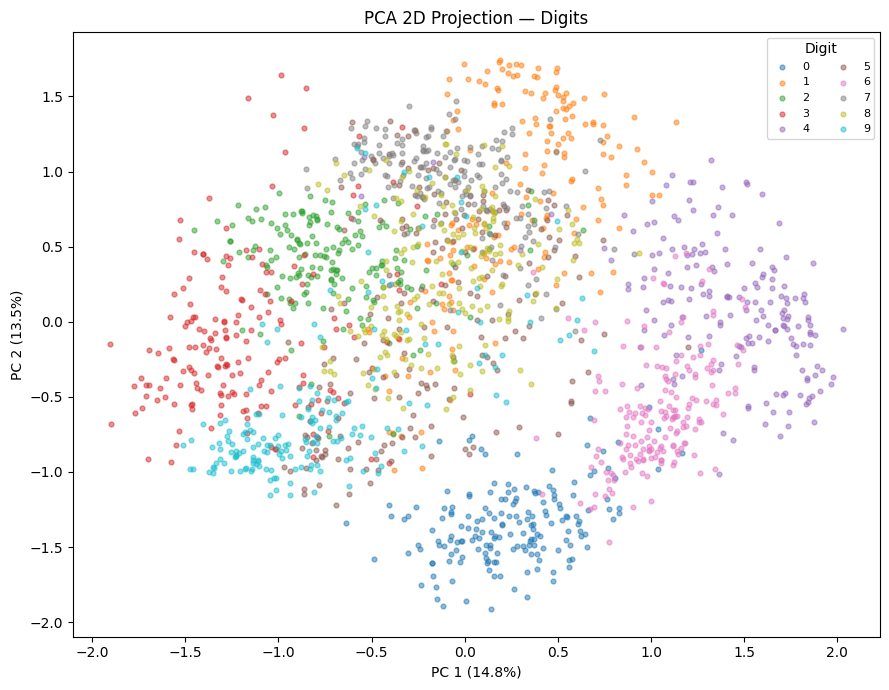

In [7]:
# ── First 12 components as 8x8 images ─────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(13, 4.5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(pca_full.components_[i].reshape(8,8), cmap="RdBu_r",
              vmin=-0.3, vmax=0.3)
    ax.set_title(f"PC {i+1}\n({pve[i]:.1%})", fontsize=8)
    ax.axis("off")
plt.suptitle("First 12 Principal Components — Digits", fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch6_pca_components.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2D projection scatter ─────────────────────────────────────────────────
pca_2d      = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca2      = pca_2d.fit_transform(X_dig_sc)
colors_dig  = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(9, 7))
for d in range(10):
    m = y_dig == d
    ax.scatter(X_pca2[m,0], X_pca2[m,1], c=[colors_dig[d]],
               alpha=0.5, s=12, label=str(d))
ax.set_xlabel(f"PC 1 ({pca_2d.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC 2 ({pca_2d.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA 2D Projection — Digits")
ax.legend(title="Digit", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES / "ch6_pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()

## t-SNE: Probabilistic Neighbourhood Embedding

### The Method

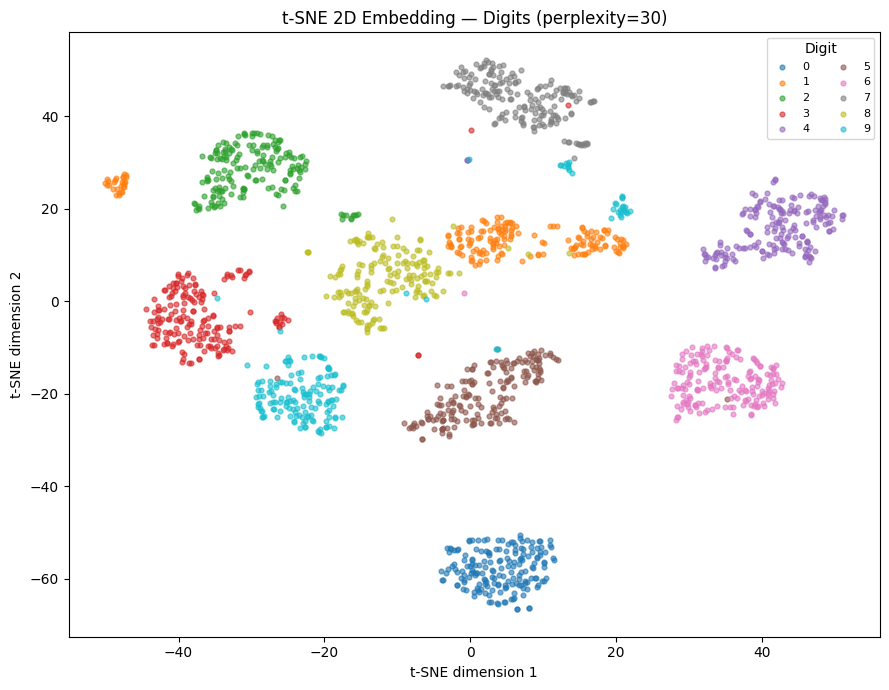

In [9]:
from sklearn.manifold import TSNE

tsne_2d   = TSNE(n_components=2, perplexity=30, max_iter=1000,
                 random_state=RANDOM_SEED)
X_tsne2   = tsne_2d.fit_transform(X_dig_sc)

fig, ax = plt.subplots(figsize=(9, 7))
for d in range(10):
    m = y_dig == d
    ax.scatter(X_tsne2[m,0], X_tsne2[m,1], c=[colors_dig[d]],
               alpha=0.6, s=12, label=str(d))
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.set_title("t-SNE 2D Embedding — Digits (perplexity=30)")
ax.legend(title="Digit", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES / "ch6_tsne_2d.png", dpi=150, bbox_inches="tight")
plt.show()

## UMAP: Uniform Manifold Approximation

### The Method

F:\project-workspace\quarto-book\data-mode-book\data-model-code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
F:\project-workspace\quarto-book\data-mode-book\data-model-code\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


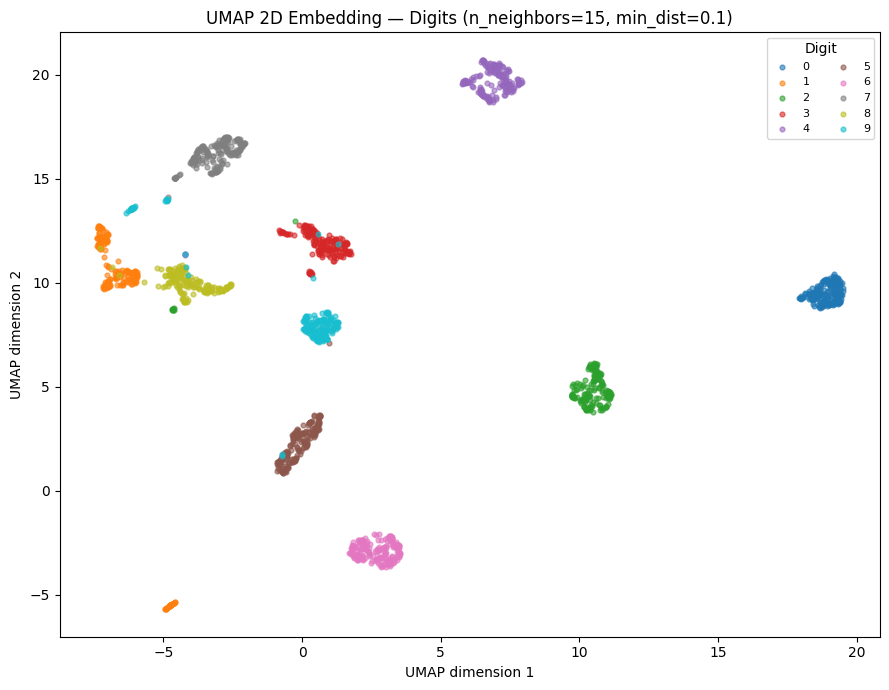

In [10]:
import umap   # pip install umap-learn

reducer     = umap.UMAP(n_components=2, n_neighbors=15,
                         min_dist=0.1, random_state=RANDOM_SEED)
X_umap2     = reducer.fit_transform(X_dig_sc)

fig, ax = plt.subplots(figsize=(9, 7))
for d in range(10):
    m = y_dig == d
    ax.scatter(X_umap2[m,0], X_umap2[m,1], c=[colors_dig[d]],
               alpha=0.6, s=12, label=str(d))
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_title("UMAP 2D Embedding — Digits (n_neighbors=15, min_dist=0.1)")
ax.legend(title="Digit", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIGURES / "ch6_umap_2d.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparing PCA, t-SNE, and UMAP

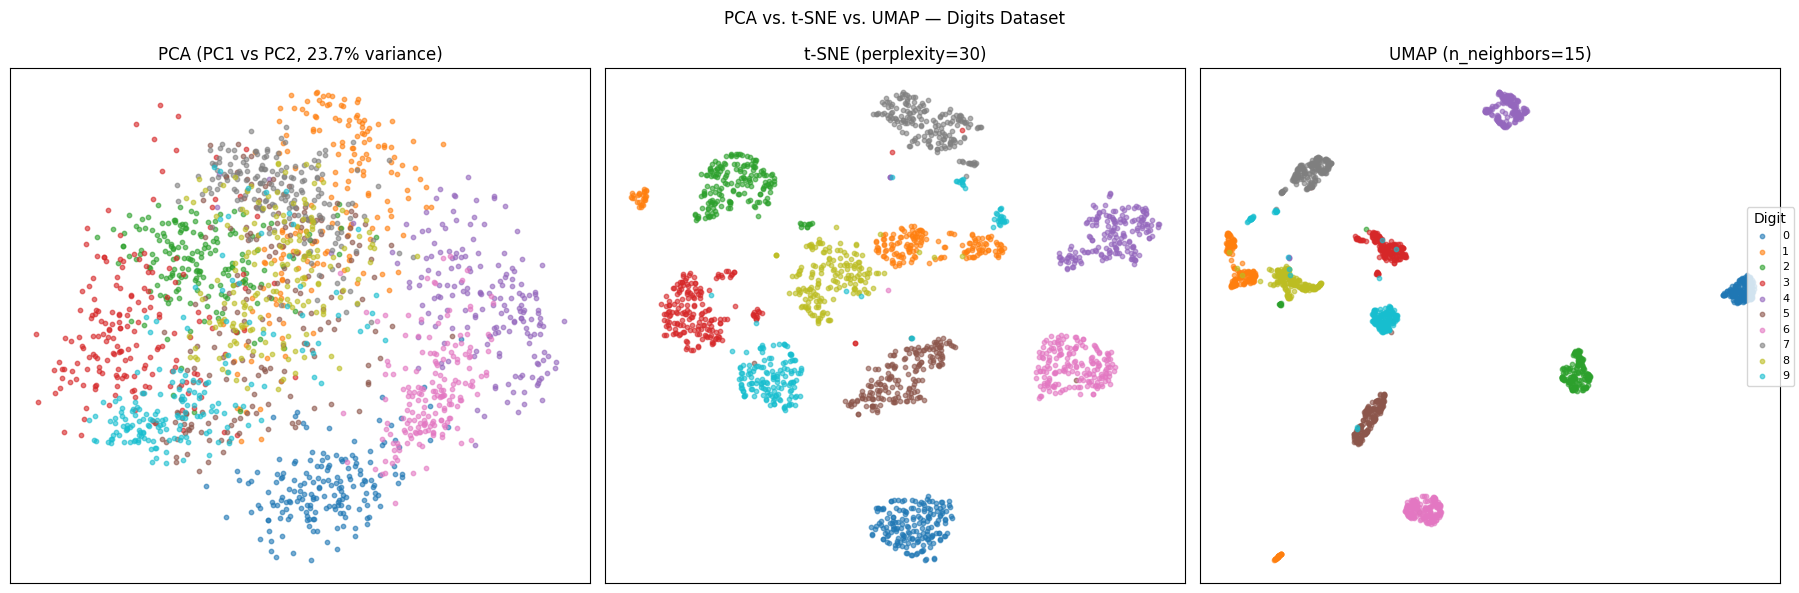

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
embeddings = [
    (X_pca2,   "PCA (PC1 vs PC2, 23.7% variance)"),
    (X_tsne2,  "t-SNE (perplexity=30)"),
    (X_umap2,  "UMAP (n_neighbors=15)"),
]
for ax, (X_emb, title) in zip(axes, embeddings):
    for d in range(10):
        m = y_dig == d
        ax.scatter(X_emb[m,0], X_emb[m,1], c=[colors_dig[d]],
                   alpha=0.6, s=10, label=str(d))
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Digit", loc="center right",
           fontsize=8, ncol=1)
plt.suptitle("PCA vs. t-SNE vs. UMAP — Digits Dataset", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "ch6_comparison.png", dpi=150, bbox_inches="tight")
plt.show()